
--- RECORRIDO VISUAL BFS ---
Visitando nodo: P
Se agrega Q a la cola
Se agrega R a la cola
Visitando nodo: Q
Se agrega S a la cola
Se agrega T a la cola
Visitando nodo: R
Se agrega U a la cola
Visitando nodo: S
Visitando nodo: T
Se agrega U a la cola
Visitando nodo: U

Recorrido final BFS: ['P', 'Q', 'R', 'S', 'T', 'U']
Memoria usada en BFS: 1608 bytes

--- RECORRRIDO VISUAL DFS ---
Visitando nodo: P
Moviéndose hacia: Q
Visitando nodo: Q
Moviéndose hacia: S
Visitando nodo: S
Moviéndose hacia: T
Visitando nodo: T
Moviéndose hacia: U
Visitando nodo: U
Moviéndose hacia: R
Visitando nodo: R

Recorrido final DFS: ['P', 'Q', 'S', 'T', 'U', 'R']
Memoria usada en DFS: 848 bytes


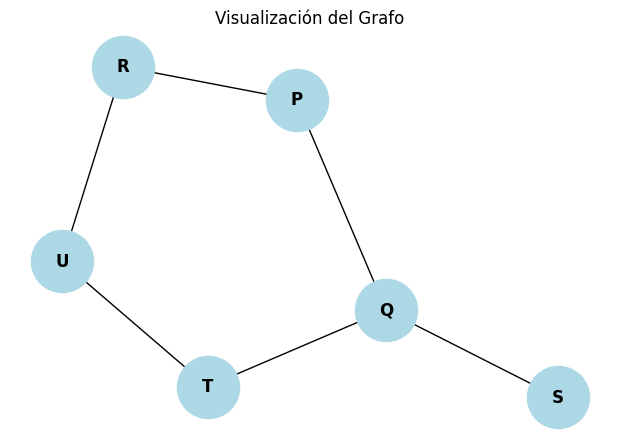

In [10]:
# Programa que implementa los algoritmos BFS y DFS
# para recorrer un grafo representado con lista de adyacencia.
# Además muestra el recorrido paso a paso y una visualización del grafo.
# Importar librerías necesarias

from collections import deque
import sys
import networkx as nx
import time
import matplotlib.pyplot as plt


# DEFINICIÓN DEL GRAFO
grafo = {
    'P': ['Q', 'R'],
    'Q': ['S', 'T'],
    'R': ['U'],
    'S': [],
    'T': ['U'],
    'U': []
}

# ALGORITMO BFS (Búsqueda en amplitud)

#BFS recorre el grafo por niveles usando una cola
def bfs(grafo, inicio):

    visitados = set()          # Guarda los nodos que ya se visitaron
    cola = deque([inicio])     # Cola que contiene los nodos por visitar
    recorrido = []             # Lista donde se guarda el recorrido final

    print("\n--- RECORRIDO VISUAL BFS ---")

    while cola:

        nodo = cola.popleft()  # Se extrae el primer elemento de la cola

        if nodo not in visitados:

            print(f"Visitando nodo: {nodo}")
            time.sleep(1)

            visitados.add(nodo)
            recorrido.append(nodo)

            # Se agregan los vecinos del nodo actual a la cola
            for vecino in grafo[nodo]:

                if vecino not in visitados:
                    cola.append(vecino)
                    print(f"Se agrega {vecino} a la cola")
                    time.sleep(1)

    # Se calcula la memoria utilizada
    memoria = sys.getsizeof(cola) + sys.getsizeof(visitados) + sys.getsizeof(recorrido)

    return recorrido, memoria


# ALGORITMO DFS (Búsqueda en profundidad)

# DFS recorre el grafo en profundidad utilizando recursividad
def dfs(grafo, inicio, visitados=None, recorrido=None):

    if visitados is None:
        visitados = set()

    if recorrido is None:
        recorrido = []

    print(f"Visitando nodo: {inicio}")
    time.sleep(1)

    visitados.add(inicio)
    recorrido.append(inicio)

    # Se recorren los vecinos del nodo actual
    for vecino in grafo[inicio]:

        if vecino not in visitados:

            print(f"Moviéndose hacia: {vecino}")
            time.sleep(1)

            dfs(grafo, vecino, visitados, recorrido)

    memoria = sys.getsizeof(visitados) + sys.getsizeof(recorrido)

    return recorrido, memoria

# EJECUCIÓN DE LOS ALGORITMOS


recorrido_bfs, memoria_bfs = bfs(grafo, 'P')

print("\nRecorrido final BFS:", recorrido_bfs)
print("Memoria usada en BFS:", memoria_bfs, "bytes")

print("\n--- RECORRRIDO VISUAL DFS ---")

recorrido_dfs, memoria_dfs = dfs(grafo, 'P')

print("\nRecorrido final DFS:", recorrido_dfs)
print("Memoria usada en DFS:", memoria_dfs, "bytes")


# VISUALIZACIÓN DEL GRAFO


G = nx.Graph()

for nodo in grafo:
    for vecino in grafo[nodo]:
        G.add_edge(nodo, vecino)

plt.figure(figsize=(6,4))

nx.draw(
    G,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_size=12,
    font_weight="bold"
)

plt.title("Visualización del Grafo")

plt.show()